In [1]:
print("welcome To Python GIS Practical")

welcome To Python GIS Practical


In [2]:
5+10


15

In [3]:
!pip install geopandas matplotlib pandas rasterio


In [4]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
gdf = gpd.read_file(r"C:\Users\naman\Desktop\INTERNSHIP\INDIA SPACE ACADMEY\23-5-26\ASSESSTS\India_District_Boundary")

In [6]:
gdf.head()

,DISTRICT_L,District,STATE,geometry
0,673,MORBI,GUJARAT,"POLYGON ((3108952.09 3942577.01, 3109009.987 3..."
1,438,AHMADABAD,GUJARAT,"POLYGON ((3193648.356 3920619.089, 3193646.392..."
2,440,ANAND,GUJARAT,"POLYGON ((3297696.184 3879979.348, 3297775.311..."
3,674,DEVBHUMI DWARKA,GUJARAT,"MULTIPOLYGON (((2924145.687 3865429.524, 29241..."
4,447,JAMNAGAR,GUJARAT,"MULTIPOLYGON (((3044918.968 3859136.847, 30448..."


In [7]:
gdf.columns  # List of columns in the GeoDataFrame

Index(['DISTRICT_L', 'District', 'STATE', 'geometry'], dtype='object')

In [8]:
gdf.crs  # Coordinate Reference System

<Projected CRS: PROJCS["LCC_WGS84",GEOGCS["WGS 84",DATUM["WGS_1984 ...>
Name: LCC_WGS84
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Lambert Conic Conformal (2SP)
Datum: World Geodetic System 1984
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

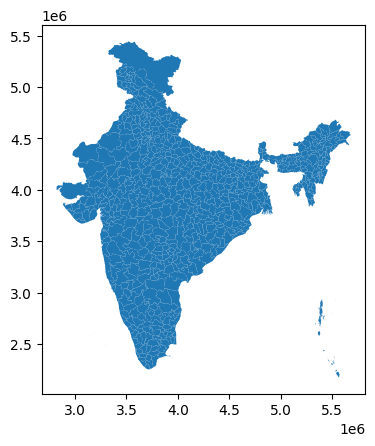

In [9]:
gdf.plot()  # Plot the GeoDataFrame
plt.show()  # Display the plot

In [10]:
jaipur = gdf[gdf["District"] == "JAIPUR"]

In [11]:
print(len(jaipur))
print(jaipur.head())


1
    DISTRICT_L District      STATE  \
174        102   JAIPUR  RAJASTHAN   

                                              geometry  
174  POLYGON ((3621382.203 4424962.359, 3621475.365...  


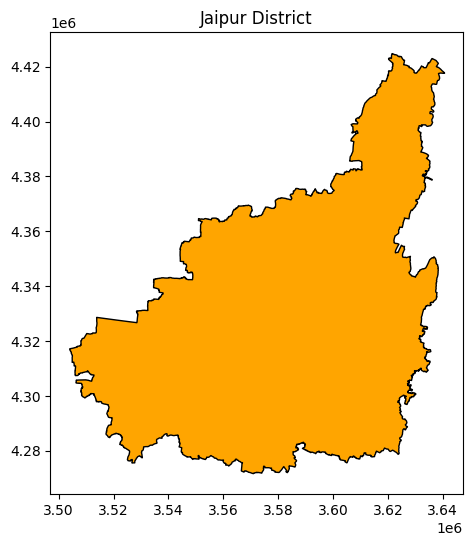

In [12]:
jaipur.plot(color="orange", edgecolor="black", figsize=(6,6))
plt.title("Jaipur District")
plt.show()

In [13]:
gdf_utm = gdf.to_crs(epsg=32643)

In [14]:
gdf_utm["area_sqkm"] = gdf_utm.geometry.area / 1000000

In [15]:
gdf_utm[["area_sqkm"]].head()

,area_sqkm
0,4999.183104
1,7250.685322
2,3176.120330
3,4189.306019
4,5948.568656


In [16]:
gdf_utm[["District", "area_sqkm"]].head()

,District,area_sqkm
0,MORBI,4999.183104
1,AHMADABAD,7250.685322
2,ANAND,3176.120330
3,DEVBHUMI DWARKA,4189.306019
4,JAMNAGAR,5948.568656


In [17]:
jaipur.to_file("Jaipur_District.shp")

In [18]:
import os
os.getcwd()

'c:\\Users\\naman\\Desktop\\INTERNSHIP\\INDIA SPACE ACADMEY\\23-5-26'

In [19]:
jaipur_buffer = jaipur.to_crs(epsg=32643)
jaipur_buffer["geometry"] = jaipur_buffer.buffer(10000)

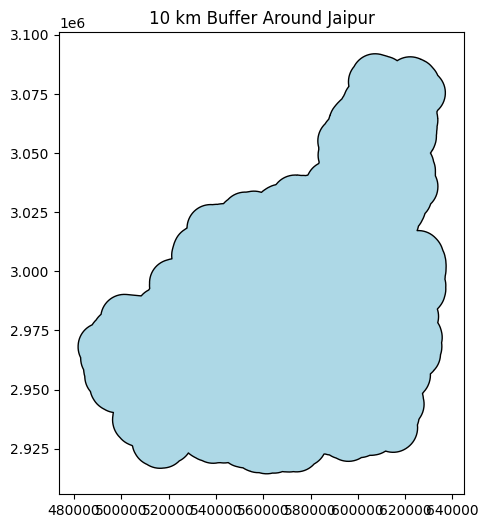

In [20]:
jaipur_buffer.plot(color="lightblue", edgecolor="black", figsize=(6,6))
plt.title("10 km Buffer Around Jaipur")
plt.show()

In [21]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

In [22]:
raster = rasterio.open(r"C:\Users\naman\Desktop\INTERNSHIP\INDIA SPACE ACADMEY\23-5-26\ASSESSTS\IND_cov_tif\IND_cov.tif")

In [23]:
print(raster)

<open DatasetReader name='C:\Users\naman\Desktop\INTERNSHIP\INDIA SPACE ACADMEY\23-5-26\ASSESSTS\IND_cov_tif\IND_cov.tif' mode='r'>


In [24]:
print(raster.meta)

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -3.3999999521443642e+38, 'width': 3528, 'height': 3468, 'count': 1, 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["unknown",SPHEROID["WGS84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST]]'), 'transform': Affine(0.008333333333333335, 0.0, 68.1,
       0.0, -0.008333333333333333, 35.6)}


[[13. 13. 13. ... 13. 13. 13.]
 [13. 13. 13. ... 13. 13. 13.]
 [13. 13. 13. ... 13. 13. 13.]
 ...
 [20. 20. 20. ... 20. 20. 20.]
 [20. 20. 20. ... 20. 20. 20.]
 [20. 20. 20. ... 20. 20. 20.]]


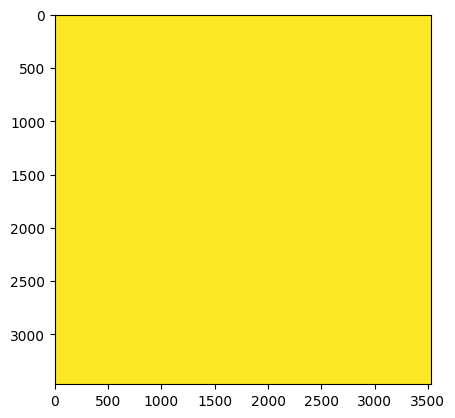

In [25]:
band1 = raster.read(1)
print(band1)
plt.imshow(band1)

In [26]:
band1= raster.read(1)

In [27]:
print(band1)

[[13. 13. 13. ... 13. 13. 13.]
 [13. 13. 13. ... 13. 13. 13.]
 [13. 13. 13. ... 13. 13. 13.]
 ...
 [20. 20. 20. ... 20. 20. 20.]
 [20. 20. 20. ... 20. 20. 20.]
 [20. 20. 20. ... 20. 20. 20.]]


lulc is land use land cover change

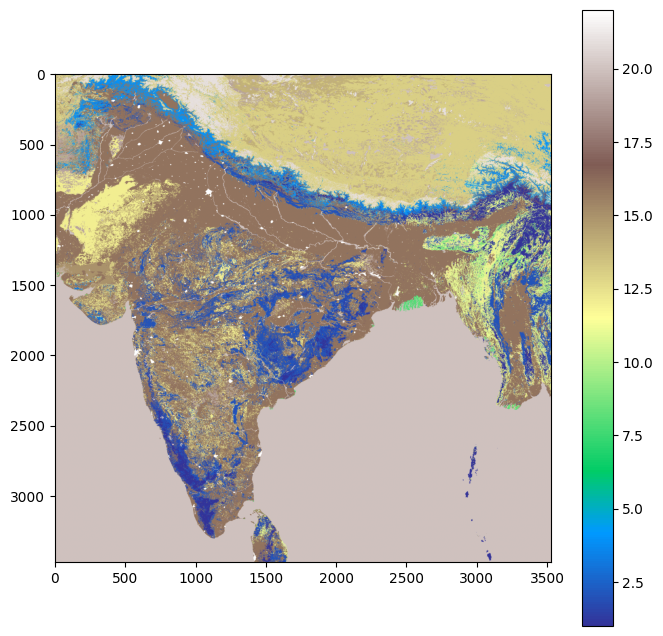

In [28]:
import numpy as np

band1 = raster.read(1)

# Replace nodata values with NaN
band1 = np.where(band1 < -1e30, np.nan, band1)

plt.figure(figsize=(8,8))
plt.imshow(band1, cmap='terrain')
plt.colorbar()
plt.show()

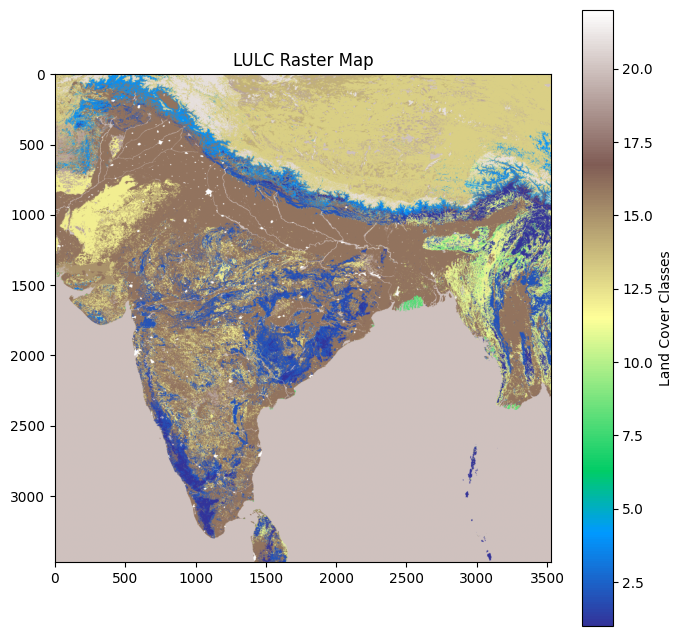

In [29]:
plt.figure(figsize=(8,8))
plt.imshow(band1, cmap="terrain")
plt.title("LULC Raster Map")
plt.colorbar(label="Land Cover Classes")
plt.show()

In [30]:
np.unique(band1)

array([ 1.,  2.,  3.,  4.,  8.,  9., 11., 12., 13., 14., 15., 16., 17.,
       19., 20., 21., 22., nan], dtype=float32)